# Recovery map from published GJ 724 residuals

Este notebook usa directamente el archivo de residuos del modelo publicado (`residuals_rvs_best_GJ724.dat`) en lugar de reconstruir los residuos restando solo la señal planetaria. Así podremos comprobar si el recovery map se aproxima más al del paper.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u

from ravex import MultiPlanetSystem, plot_detectability_map


## Cargar los residuos publicados

In [2]:

# The file appears to contain five columns:
# BJD, residual_RV, e_RV, instrument, extra_model_column
#
# We use the second column as the residual RV series, because:
# - it is centred close to zero,
# - its rms is comparable to the quoted uncertainties,
# - and it is consistent with a residual time series ready for injection-recovery tests.

colnames = ["BJD", "RV_resid", "e_RV", "Inst", "extra_col"]

df = pd.read_csv(
    "residuals_rvs_best_GJ724.dat",
    sep=r"\s+",
    comment="#",
    names=colnames
)

df["Inst"] = df["Inst"].astype(str).str.strip()
df = df.sort_values("BJD").reset_index(drop=True)

print(df.head())
print()
print(df["Inst"].value_counts())
print()
print(df[["RV_resid", "e_RV", "extra_col"]].describe())


            BJD  RV_resid   e_RV   Inst  extra_col
0  2.454566e+06 -0.259377  1.976  HARPS   8.530377
1  2.454662e+06  0.052601  1.340  HARPS   1.125399
2  2.454663e+06  0.193683  1.489  HARPS   9.503317
3  2.454664e+06  1.618663  1.347  HARPS  -3.580663
4  2.454665e+06  0.904701  2.053  HARPS  -5.168701

Inst
CARM-VIS    83
HARPS       27
Name: count, dtype: int64

         RV_resid        e_RV   extra_col
count  110.000000  110.000000  110.000000
mean     0.116413    1.829267    0.543553
std      1.761782    0.605800    4.838351
min     -4.362371    1.072000   -8.107663
25%     -0.765656    1.380902   -3.080829
50%     -0.047321    1.696650   -0.040466
75%      0.923027    2.075765    2.753475
max      8.726292    4.624847   14.024484


## Construir la serie temporal para el mapa de detectabilidad

In [3]:

# Adopted stellar mass from Gorrini et al. (2023)
mass_star = 0.5271 * u.solMass

# Time series used for the recovery map
jd = df["BJD"].to_numpy(dtype=float)
rv_residual = df["RV_resid"].to_numpy(dtype=float)
rv_err = df["e_RV"].to_numpy(dtype=float)
inst = df["Inst"].to_numpy()

# No extra jitter is added here by default, because these are already published residuals.
# If you later decide to test a more conservative map, define for example:
# rv_err_eff = np.sqrt(rv_err**2 + 1.0**2)
rv_err_eff = rv_err.copy()

print(f"Total number of RVs: {len(jd)}")
print(f"Time span: {jd.max() - jd.min():.1f} days")
print(f"Residual RMS: {np.std(rv_residual, ddof=1):.3f} m/s")
print(f"Mean quoted error: {np.mean(rv_err_eff):.3f} m/s")
print()

for name in np.unique(inst):
    m = inst == name
    print(
        f"{name:10s}  N = {m.sum():3d}   "
        f"<e_RV> = {rv_err_eff[m].mean():.3f} m/s   "
        f"RMS(residuals) = {np.std(rv_residual[m], ddof=1):.3f} m/s"
    )


Total number of RVs: 110
Time span: 5247.5 days
Residual RMS: 1.762 m/s
Mean quoted error: 1.829 m/s

CARM-VIS    N =  83   <e_RV> = 1.938 m/s   RMS(residuals) = 1.911 m/s
HARPS       N =  27   <e_RV> = 1.496 m/s   RMS(residuals) = 1.220 m/s


## Inspección rápida de los residuos

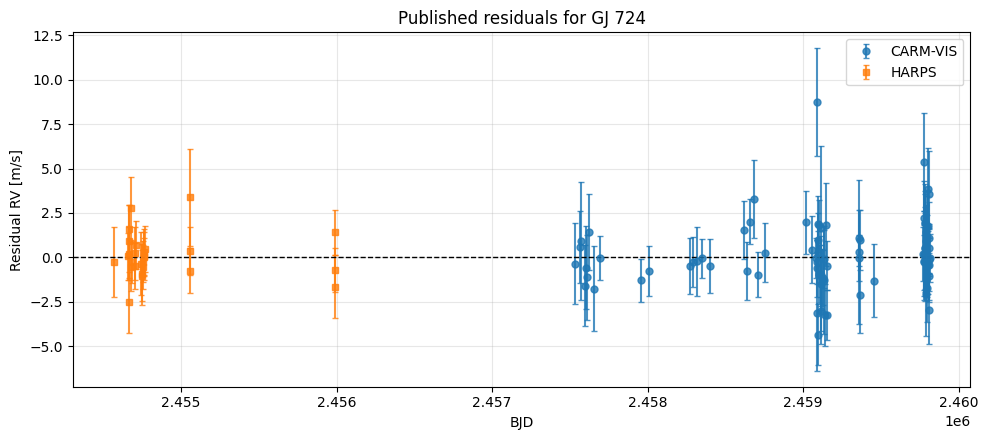

In [4]:

m_carm = inst == "CARM-VIS"
m_harps = inst == "HARPS"

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.errorbar(
    jd[m_carm], rv_residual[m_carm],
    yerr=rv_err_eff[m_carm],
    fmt="o", ms=5, capsize=2,
    label="CARM-VIS", alpha=0.8
)

ax.errorbar(
    jd[m_harps], rv_residual[m_harps],
    yerr=rv_err_eff[m_harps],
    fmt="s", ms=5, capsize=2,
    label="HARPS", alpha=0.8
)

ax.axhline(0.0, color="k", ls="--", lw=1)
ax.set_xlabel("BJD")
ax.set_ylabel("Residual RV [m/s]")
ax.set_title("Published residuals for GJ 724")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Definir el sistema base para las inyecciones

Aunque trabajamos sobre residuos, `ravex` necesita la masa estelar para convertir masa planetaria en amplitud RV.

In [5]:

system724_resid = MultiPlanetSystem(
    mass_main=mass_star,
    planets=[]
)


## Grid del recovery map

In [21]:

period_grid = np.logspace(np.log10(1.0), np.log10(150.0), 50)
msini_grid = np.logspace(np.log10(0.5), np.log10(50.0), 50)
n_phase = 50

print("Full grid:")
print("  N_periods =", len(period_grid))
print("  N_masses  =", len(msini_grid))
print("  n_phase   =", n_phase)
print("  total recoveries =", len(period_grid) * len(msini_grid) * n_phase)


Full grid:
  N_periods = 50
  N_masses  = 50
  n_phase   = 50
  total recoveries = 125000


## Configuración del recovery

In [22]:

criterion = "period+fap"
period_tol = 0.05
fap_alpha = 0.01

phase_mode = "grid"
eccentricity_inj = 0.0
argument_periapse_inj = 90.0 * u.deg

fap_method = "baluev"
samples_per_peak = 10
nyquist_factor = 5
search_pad_factor = 1.25

n_jobs = 32   # adjust to your machine

print("Recovery settings:")
print(f"criterion         = {criterion}")
print(f"period_tol        = {period_tol:.2f}")
print(f"fap_alpha         = {fap_alpha:.3f}")
print(f"phase_mode        = {phase_mode}")
print(f"eccentricity_inj  = {eccentricity_inj:.1f}")
print(f"fap_method        = {fap_method}")
print(f"samples_per_peak  = {samples_per_peak}")
print(f"nyquist_factor    = {nyquist_factor}")
print(f"search_pad_factor = {search_pad_factor}")
print(f"n_jobs            = {n_jobs}")


Recovery settings:
criterion         = period+fap
period_tol        = 0.05
fap_alpha         = 0.010
phase_mode        = grid
eccentricity_inj  = 0.0
fap_method        = baluev
samples_per_peak  = 10
nyquist_factor    = 5
search_pad_factor = 1.25
n_jobs            = 32


## Lanzar el recovery map

In [23]:

res_map_724_published = system724_resid.detectability_map_from_series_parallel(
    ts=jd,
    rv=rv_residual,
    rv_err=rv_err_eff,
    period_grid=period_grid,
    msini_grid=msini_grid,
    n_phase=n_phase,
    phase_mode=phase_mode,
    eccentricity=eccentricity_inj,
    argument_periapse=argument_periapse_inj,
    criterion=criterion,
    period_tol=period_tol,
    fap_alpha=fap_alpha,
    fap_method=fap_method,
    samples_per_peak=samples_per_peak,
    nyquist_factor=nyquist_factor,
    search_pad_factor=search_pad_factor,
    rng_seed=42,
    n_jobs=n_jobs,
    verbose=True
)

print("Recovery map completed.")
print("Available output keys:")
print(sorted(res_map_724_published.keys()))


[detectability_map_parallel] tasks=2500, n_jobs=32, chunksize=1
Recovery map completed.
Available output keys:
['chunksize', 'criterion', 'eccentricity', 'fap_alpha', 'fap_method', 'k_tol', 'median_fap', 'median_k_relerr', 'median_p_best_days', 'median_sigma', 'mp_start_method', 'msini_grid_mearth', 'n_jobs', 'n_phase', 'nyquist_factor', 'period_grid_days', 'period_hit_rate', 'period_tol', 'phase_mode', 'recovery_rate', 'samples_per_peak', 'search_range_days']


## Visualizar el resultado

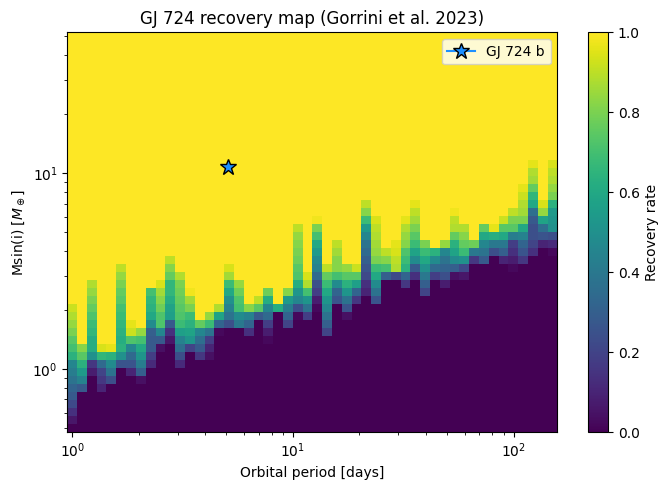

In [26]:

fig, ax = plt.subplots(figsize=(7, 5))

plot_detectability_map(
    res_map_724_published,
    key="recovery_rate",
    ax=ax,
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    log_period=True,
    log_msini=True,
    colorbar=True,
    cbar_label="Recovery rate"
)

# Known published planet, overplotted only for reference
ax.plot(
    5.101284, 10.75,
    marker="*",
    markersize=12,
    color="dodgerblue",
    markeredgecolor="k",
    zorder=5,
    label="GJ 724 b"
)

ax.legend(loc="best")
ax.set_title("GJ 724 recovery map (Gorrini et al. 2023)")
plt.tight_layout()


plt.show()


## Guardar el resultado opcionalmente

In [25]:

#Optional
np.savez("gj724_recovery_map_published_residuals.npz", **res_map_724_published)
